# Fine-tuning a Pre-trained Convolutional Neural Network for the Grainset Image Dataset

For our Neural Network, we will use a pre-trained model in order to perform classification tasks. We chose a CNN model, specifically EfficientNetV2-small, in order to utilize its convolutional blocks that can extract features from images and is still a relatively small model.

In [1]:
from lightning.pytorch.loggers import CometLogger
import matplotlib.pyplot as plt
from neural_network_utils import (
    GrainDataModule,
    IDX_TO_CLASS,
    LightningModel,
    plot_loss_and_acc,
)
import lightning as L
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%load_ext watermark
%watermark -p torch,lightning,torchvision,torchmetrics


torch       : 2.10.0
lightning   : 2.6.1
torchvision : 0.25.0
torchmetrics: 1.8.2



## Preparing the Pre-Trained Model

We will use the EfficientNetV2-small model pretrained using the Imagenet1K-v1 dataset in order to leverage the feature extraction ability that the model has acquired when training the model on the thousands of classes on the dataset.

In [3]:
efficientnet_v2_s = torch.hub.load(
    "pytorch/vision:v0.25.0", "efficientnet_v2_s", weights="IMAGENET1K_V1"
)

Using cache found in /home/xandreiathome/.cache/torch/hub/pytorch_vision_v0.25.0


In [4]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

For this project, we will not train the whole model as it will be computationally expensive. Instead we will train the last 3 convolutional blocks in order to for those blocks to adapt to our dataset. This will also leverage the capability of the earlier convolutional blocks of EfficientNet, to extract the generic features of an image.

Reference: https://www.identifyshell.org/blog-fine-tuning-efficientnetv2-models.php

In [5]:
for param in efficientnet_v2_s.features[:5].parameters():
    param.requires_grad = False

for param in efficientnet_v2_s.features[5:].parameters():
    param.requires_grad = True

efficientnet_v2_s.classifier[1] = torch.nn.Linear(1280, 14)

In [6]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

Get the preprocessing of the EfficientNet architecture to reuse on the validation and test dataloaders

In [7]:
from torchvision.models import EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

We will also add some augmentations for the training set. A weighted sampler for the training set is also implemented in the DataModule in order to mitigate the class imbalance in the dataset.

In [8]:
import torchvision.transforms as T

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
train_transform = T.Compose(
    [
        T.Resize(384),
        T.CenterCrop(384),
        T.RandomHorizontalFlip(),
        T.RandomRotation(20),
        T.ColorJitter(0.05, 0.05, 0.05),
        T.ToTensor(),
        T.Normalize(mean, std),
    ]
)

## Preparing the Dataset and Loaders
A quick check in order to make sure that the dataloader is able to load the images properly

In [9]:
data_module = GrainDataModule(
    data_dir="dataset/images",
    batch_size=16,
    train_transform=train_transform,
    val_transform=preprocess_transform,
    test_transform=preprocess_transform,
)

In [10]:
data_module.setup()

In [11]:
print("Train size:", len(data_module.train_dataset))
print("Val size:", len(data_module.val_dataset))
print("Test size:", len(data_module.test_dataset))

Train size: 34395
Val size: 6067
Test size: 4500


We used a weighted sampling in order to address the class imbalance in the dataset. Let's check if it working and not sampling the majority classes which are rice_0_NOR and maize_0_nor.

torch.Size([16, 3, 384, 384])
torch.Size([16])


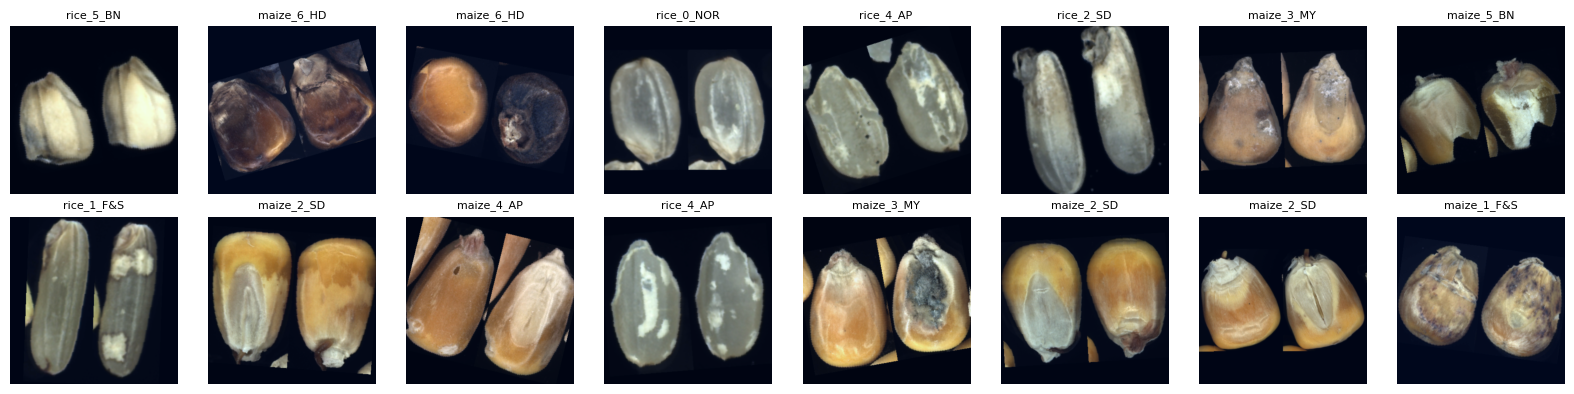

Displayed 16 images from the batch
CLASS DISTRIBUTION IN BATCH
maize_2_SD: 3 images (18.8%)
maize_6_HD: 2 images (12.5%)
rice_4_AP: 2 images (12.5%)
maize_3_MY: 2 images (12.5%)
rice_5_BN: 1 images (6.2%)
rice_0_NOR: 1 images (6.2%)
rice_2_SD: 1 images (6.2%)
maize_5_BN: 1 images (6.2%)
rice_1_F&S: 1 images (6.2%)
maize_4_AP: 1 images (6.2%)
maize_1_F&S: 1 images (6.2%)


In [ ]:
train_loader = data_module.train_dataloader()

batch_images, batch_labels = next(iter(train_loader))

print(batch_images.shape)
print(batch_labels.shape)

# Display all images in the batch in a grid
n_images = batch_images.shape[0]
n_cols = 8
n_rows = (n_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
axes = axes.flatten()

for idx in range(n_images):
    img = batch_images[idx].permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-5)

    axes[idx].imshow(img.cpu().numpy())
    class_label = IDX_TO_CLASS[batch_labels[idx].item()]
    axes[idx].set_title(class_label, fontsize=8)
    axes[idx].axis("off")

for idx in range(n_images, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

print(f"Displayed {n_images} images from the batch\n")

print("CLASS DISTRIBUTION IN BATCH")

class_counts = {}
for label_idx in batch_labels:
    class_name = IDX_TO_CLASS[label_idx.item()]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Sort by counts descending
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

for class_name, count in sorted_classes:
    percentage = (count / n_images) * 100
    print(f"{class_name}: {count} images ({percentage:.1f}%)")

# Preparing Hyperparameters for the Model

We will use the utility tuners that come with Lightning in order to find a good baseline for the learning rate and batch sizes.

In [13]:
L.seed_everything(67)

num_epochs = 1
num_steps = num_epochs * len(data_module.train_dataloader())
lightning_model = LightningModel(
    model=efficientnet_v2_s,
    learning_rate=9.120108393559096e-06,
    num_classes=14,
    cosine_t_max=num_steps,
)

debug_trainer = L.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=None,
    deterministic=True,
    precision="16-mixed",
)

Seed set to 67
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [14]:
from lightning.pytorch.tuner import Tuner

tuner = Tuner(debug_trainer)

In [ ]:
new_batch_size = tuner.scale_batch_size(
    model=lightning_model, datamodule=data_module, mode="power"
)

print(new_batch_size)

In [ ]:
data_module.batch_size = 16

In [ ]:
lr_finder = tuner.lr_find(lightning_model, datamodule=data_module)

fig = lr_finder.plot(suggest=True)
fig.show()

new_lr = lr_finder.suggestion()
print(new_lr)

In [ ]:
lightning_model.learning_rate = new_lr

## Traing the Model

We will use CosineAnnealing learning rate scheduler alongside Adam optimizer in order to improve the loss convergence of the model. Alongside this, we used [label smoothing](https://arxiv.org/abs/1512.00567) on the cross entropy loss. This makes it so that instead of the true label being one-hot encoded, we use a hyperparameter α, so that other classes also get a small value. This helps the model to not get overconfident in its predictions and reduce overfitting. 

In [15]:
from lightning.pytorch.callbacks import ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        save_top_k=1,
        mode="min",
        monitor="val_loss",
        save_last=True,
        dirpath="./checkpoints",
        filename="efficientnet-{epoch:02d}-{val_loss:.2f}",
    )
]

In [ ]:
comet_logger = CometLogger(
    name="lightning_logs_local",  # Optional
)

In order to shorten the training time, we used 16bit Mixed precision for training the model.

In [16]:
trainer = L.Trainer(
    max_epochs=num_epochs,
    accelerator="gpu",
    devices="auto",
    logger=[CSVLogger(save_dir="logs/", name="tuned-efficientnet")],
    deterministic=True,
    precision="16-mixed",
    callbacks=callbacks,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(model=lightning_model, datamodule=data_module)

We used the epoch 39 checkpoint as our final model weights, as it produced the lowest validation loss.

In [18]:
lightning_model.eval()

LightningModel(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d

In [23]:
trainer.test(
    model=lightning_model,
    datamodule=data_module,
    ckpt_path="checkpoints/checkpoint_efficientnet-epoch=39-val_loss=0.56.ckpt",
)

Restoring states from the checkpoint path at checkpoints/checkpoint_efficientnet-epoch=39-val_loss=0.56.ckpt
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: The dirpath has changed from '/teamspace/studios/this_studio/checkpoint' to '/home/xandreiathome/Work/class-code/mco/image-recognition-mco/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at checkpoints/checkpoint_efficientnet-epoch=39-val_loss=0.56.ckpt
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric         ┃        DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_acc          │     0.9882222414016724     │
│    test_f1_maize_0_NOR     │     0.9980040192604065     │
│    test_f1_maize_1_F&S     │     0.9950248599052429     │
│     test_f1_maize_2_SD     │     0.9949748516082764     │
│     test_f1_maize_3_MY     │     0.9746192693710327     │
│     test_f1_maize_4_AP     │     0.9950248599052429     │
│     test_f1_maize_5_BN     │            1.0             │
│     test_f1_maize_6_HD     │     0.9847715497016907     │
│     test_f1_rice_0_NOR     │     0.9916855692863464     │
│     test_f1_rice_1_F&S     │     0.9867549538612366     │
│     test_f1_rice_2_SD      │     0.9254658222198486     │
│     test_f1_rice_3_MY      │     0.9704918265342712     │
│     test_f1_rice_4_AP      │     0.9898989796638489     │
│     test_f1_rice_5_BN      │     0.9798657894134521     │
│     test_f1_rice_6_UN      │     0.9610389471054077     │
│       test_macro_f1        │     0.9819729328155518     │
│    test_macro_precision    │     0.9778552651405334     │
│     test_macro_recall      │     0.9869524240493774     │
│ test_precision_maize_0_NOR │     0.9960159659385681     │
│ test_precision_maize_1_F&S │     0.9900990128517151     │
│ test_precision_maize_2_SD  │            1.0             │
│ test_precision_maize_3_MY  │     0.9896907210350037     │
│ test_precision_maize_4_AP  │     0.9900990128517151     │
│ test_precision_maize_5_BN  │            1.0             │
│ test_precision_maize_6_HD  │            1.0             │
│ test_precision_rice_0_NOR  │     0.9994921088218689     │
│ test_precision_rice_1_F&S  │     0.9802631735801697     │
│  test_precision_rice_2_SD  │     0.8662790656089783     │
│  test_precision_rice_3_MY  │     0.9548386931419373     │
│  test_precision_rice_4_AP  │            1.0             │
│  test_precision_rice_5_BN  │     0.9864864945411682     │
│  test_precision_rice_6_UN  │     0.9367088675498962     │
│  test_recall_maize_0_NOR   │            1.0             │
│  test_recall_maize_1_F&S   │            1.0             │
│   test_recall_maize_2_SD   │     0.9900000095367432     │
│   test_recall_maize_3_MY   │     0.9599999785423279     │
│   test_recall_maize_4_AP   │            1.0             │
│   test_recall_maize_5_BN   │            1.0             │
│   test_recall_maize_6_HD   │     0.9700000286102295     │
│   test_recall_rice_0_NOR   │     0.984000027179718      │
│   test_recall_rice_1_F&S   │     0.9933333396911621     │
│   test_recall_rice_2_SD    │     0.9933333396911621     │
│   test_recall_rice_3_MY    │     0.9866666793823242     │
│   test_recall_rice_4_AP    │     0.9800000190734863     │
│   test_recall_rice_5_BN    │     0.9733333587646484     │
│   test_recall_rice_6_UN    │     0.9866666793823242     │
└────────────────────────────┴────────────────────────────┘

[{'test_acc': 0.9882222414016724,
  'test_macro_precision': 0.9778552651405334,
  'test_macro_recall': 0.9869524240493774,
  'test_macro_f1': 0.9819729328155518,
  'test_precision_maize_0_NOR': 0.9960159659385681,
  'test_recall_maize_0_NOR': 1.0,
  'test_f1_maize_0_NOR': 0.9980040192604065,
  'test_precision_maize_1_F&S': 0.9900990128517151,
  'test_recall_maize_1_F&S': 1.0,
  'test_f1_maize_1_F&S': 0.9950248599052429,
  'test_precision_maize_2_SD': 1.0,
  'test_recall_maize_2_SD': 0.9900000095367432,
  'test_f1_maize_2_SD': 0.9949748516082764,
  'test_precision_maize_3_MY': 0.9896907210350037,
  'test_recall_maize_3_MY': 0.9599999785423279,
  'test_f1_maize_3_MY': 0.9746192693710327,
  'test_precision_maize_4_AP': 0.9900990128517151,
  'test_recall_maize_4_AP': 1.0,
  'test_f1_maize_4_AP': 0.9950248599052429,
  'test_precision_maize_5_BN': 1.0,
  'test_recall_maize_5_BN': 1.0,
  'test_f1_maize_5_BN': 1.0,
  'test_precision_maize_6_HD': 1.0,
  'test_recall_maize_6_HD': 0.9700000286102

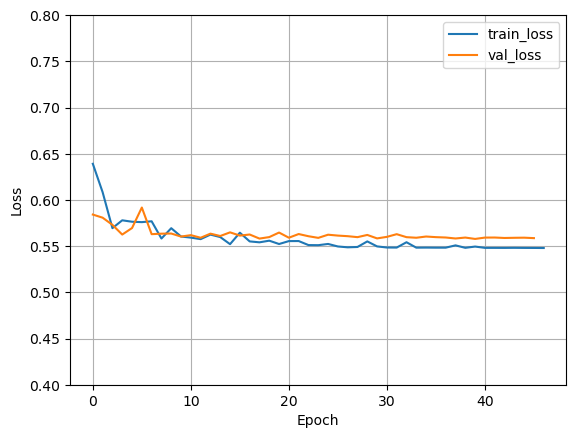

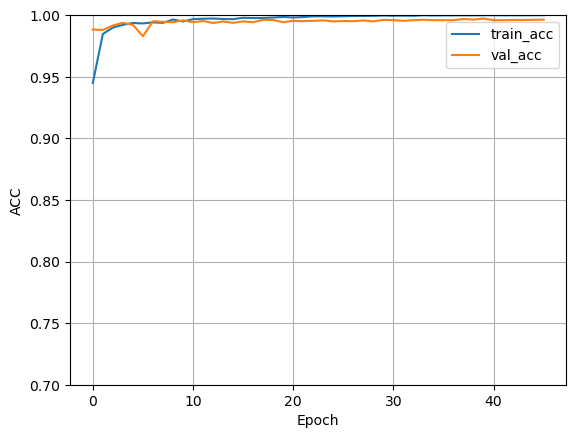

In [27]:
# plot_loss_and_acc(log_dir=trainer.logger.log_dir, loss_ylim=(0.0, 2.0))
plot_loss_and_acc(log_dir="logs/tuned-efficientnet/version_1", loss_ylim=(0.4, 0.8))

## Test Confusion Matrix
Let's generate the confusion matrix for the test dataset to visualize the model's performance on the test data.

Predicting Test Set:   0%|          | 0/282 [00:00<?, ?it/s]

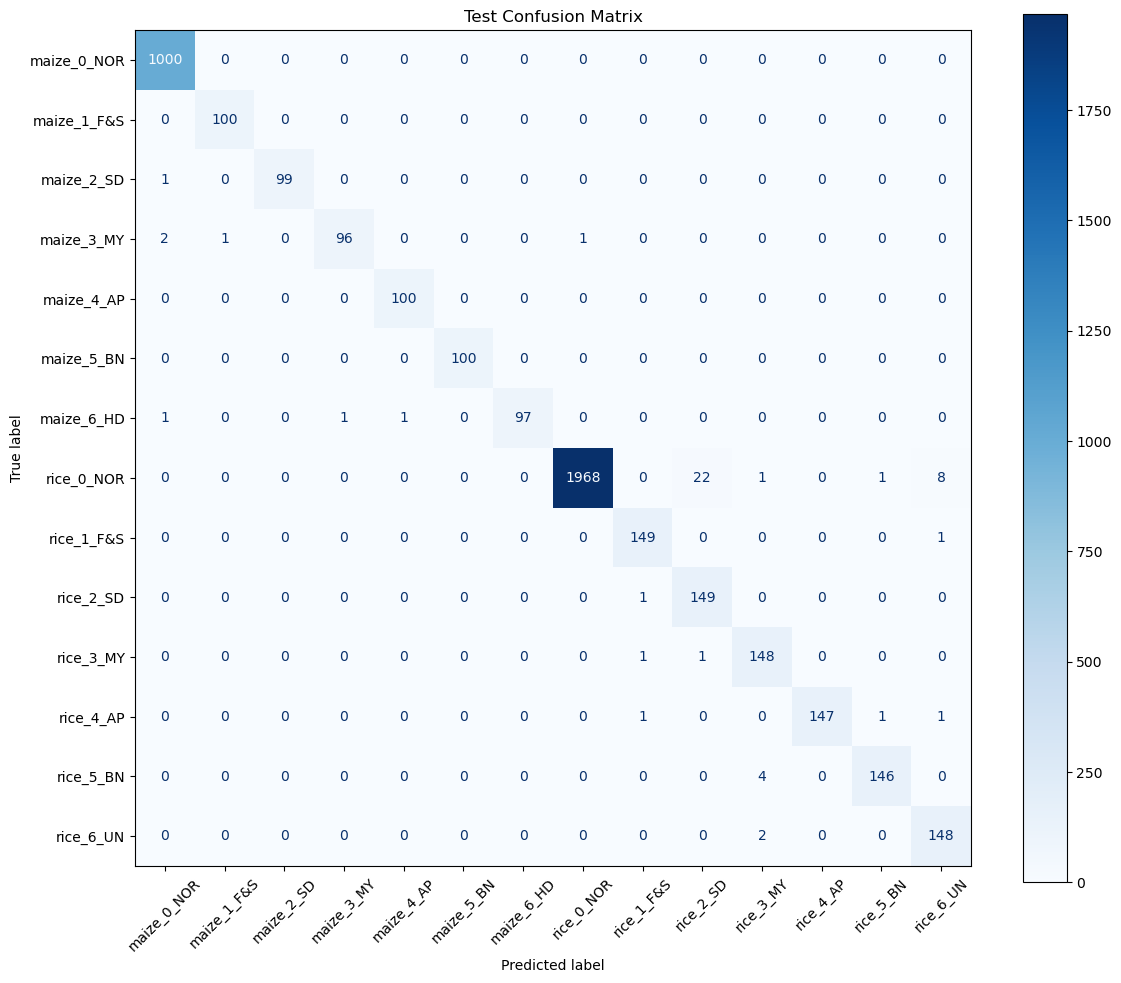

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm.auto import tqdm
import torch

test_dataloader = data_module.test_dataloader()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lightning_model.to(device)
lightning_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in tqdm(test_dataloader, desc="Predicting Test Set"):
        images = images.to(device)
        logits = lightning_model(images)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
labels = [IDX_TO_CLASS[i] for i in range(len(IDX_TO_CLASS))]

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.show()